# 1- Data Preprocessing

### 1.1 Loading data 

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/Users/Safa/code/Reenad-Alzahrani/Medical_Insurance_Cost_Prediction/raw_data/medical_insurance.csv')
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


### 1.2 Inspect the schema (columns and shape)

In [3]:
# Check the shape (rows, columns)
print("Shape of the dataset:", df.shape)

Shape of the dataset: (100000, 54)


**The dataset has 100,000 rows and 54 columns — a large dataset with many features to analyze.**

In [4]:
# Check the column names
print("Column names:", df.columns.tolist())

Column names: ['person_id', 'age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']


**The dataset includes 54 columns covering personal, health, and insurance-related attributes**

#### Inspect data types

In [5]:
# Show data types of each column
print(df.dtypes)

person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                       int64
copay                    

**Most columns are numeric (`int64`, `float64`), suitable for analysis and modeling, while several categorical features (`object`) describe demographic or plan information — indicating a mix of quantitative and qualitative data**

In [6]:
# detailed overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

**All columns have complete data except **`alcohol_freq`**, which has missing values (~30% nulls).
The dataset includes mostly numeric fields with some categorical (`object`) ones, indicating it's well-structured and ready for analysis after handling the missing column**

#### Check for missing values

In [7]:
# Sort to see the columns with the most missing data first
print(df.isnull().sum().sort_values(ascending=False))

alcohol_freq                   30083
person_id                          0
sex                                0
region                             0
urban_rural                        0
age                                0
income                             0
education                          0
employment_status                  0
marital_status                     0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_term_years                  0
p

**Only the column **`alcohol_freq`** has missing values (30,083 entries), while all other columns are complete — indicating minimal data cleaning is needed before analysis.**

#### Get descriptive statistics

In [8]:
# Get basic statistics for numeric and categorical columns
df.describe(include='all')

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,100000,100000,100000,1.000000e+05,100000,100000,100000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
unique,NaN,NaN,3,5,3,NaN,6,4,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,South,Urban,NaN,Bachelors,Married,Employed,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,49193,28029,60019,NaN,27996,53252,55269,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,50000.500000,47.521500,NaN,NaN,NaN,4.987390e+04,NaN,NaN,NaN,2.430900,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,NaN,NaN,NaN,4.680021e+04,NaN,NaN,NaN,1.075126,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,NaN,NaN,NaN,1.100000e+03,NaN,NaN,NaN,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,NaN,NaN,NaN,2.110000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,NaN,NaN,NaN,3.620000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,NaN,NaN,NaN,6.220000e+04,NaN,NaN,NaN,3.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000


**The dataset shows a mix of numeric and categorical columns.**

* Numeric columns like `age`, `income`, `bmi`, and medical procedure counts have meaningful statistics: mean, std, min, max, and percentiles.
* Categorical columns (`sex`, `region`, `education`, etc.) show the most frequent values (`top`) and their counts (`freq`).
* This summary helps quickly identify distributions, ranges, and common categories, providing a good overview before analysis.

### 1.3 Handle missing data

In [9]:
#counting the percentage of NaN for each coulmn
df.isnull().sum().sort_values(ascending=False) / len(df)

alcohol_freq                   0.30083
person_id                      0.00000
sex                            0.00000
region                         0.00000
urban_rural                    0.00000
age                            0.00000
income                         0.00000
education                      0.00000
employment_status              0.00000
marital_status                 0.00000
household_size                 0.00000
dependents                     0.00000
bmi                            0.00000
smoker                         0.00000
visits_last_year               0.00000
hospitalizations_last_3yrs     0.00000
days_hospitalized_last_3yrs    0.00000
medication_count               0.00000
systolic_bp                    0.00000
diastolic_bp                   0.00000
ldl                            0.00000
hba1c                          0.00000
plan_type                      0.00000
network_tier                   0.00000
deductible                     0.00000
copay                    

In [10]:
# Count the number of missing values in the 'alcohol_freq' column
missing_rows = df['alcohol_freq'].isnull().sum()
print("missing values:", missing_rows)

missing values: 30083


In [11]:
#percentage of missing values in alcohol_freq
(df.alcohol_freq.isnull().sum() / len(df))

np.float64(0.30083)

The result 0.30083 means that about 30% of the values in the alcohol_freq column are missing.

This is a relatively large proportion, so deleting all rows with missing values is not recommended, because we just lose roughly one-third of our data.

In [12]:
# Display the frequency of each category in the 'alcohol_freq' column
df['alcohol_freq'].value_counts()

alcohol_freq
Occasional    45078
Weekly        19833
Daily          5006
Name: count, dtype: int64

The output shows the distribution of values in the alcohol_freq column.
There are three categories: Occasional, Weekly, and Daily so we do impute missing value with the most frequent value(mode).
The majority of individuals fall into the Occasional group (45,078).
followed by Weekly drinkers (19,833), and Daily drinkers (5,006).

In [13]:
# Impute missing values in the 'alcohol_freq' column with the most frequent value (mode)
df['alcohol_freq'].fillna(df['alcohol_freq'].mode()[0], inplace=True)

/var/folders/5y/6939r6q57sx9738c92nhs3d80000gn/T/ipykernel_21051/3212561218.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['alcohol_freq'].fillna(df['alcohol_freq'].mode()[0], inplace=True)


In [14]:
df['alcohol_freq'].isnull().sum()

np.int64(0)

The alcohol_freq column is categorical with three levels: Occasional, Weekly, and Daily

Since about 30% of the data was missing, missing values were imputed using the most frequent category (Occasional).

### 1.4 Normalize column names and formats

#### we make this function to standardize naming and formatting for consistency.

In [15]:
df.columns

Index(['person_id', 'age', 'sex', 'region', 'urban_rural', 'income',
       'education', 'marital_status', 'employment_status', 'household_size',
       'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year',
       'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs',
       'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
       'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years',
       'policy_changes_last_2yrs', 'provider_quality', 'risk_score',
       'annual_medical_cost', 'annual_premium', 'monthly_premium',
       'claims_count', 'avg_claim_amount', 'total_claims_paid',
       'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd',
       'cardiovascular_disease', 'cancer_history', 'kidney_disease',
       'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count',
       'proc_surgery_count', 'proc_physio_count', 'proc_consult_count',
       'proc_lab_count', 'is_high_risk', 'had_major_procedure'],
      

In [16]:
def normalize_column_names(data):
    return data.columns.str.strip().str.lower().str.replace(' ', '_')

In [17]:
df.columns = normalize_column_names(df)

### 1.5 clean data

#### cheak for duplication

In [18]:
df.duplicated().sum()

np.int64(0)

##### the data is clean and not duplicated

#### Cheak columns with unreasonable or incorrect values

In [19]:
df.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [20]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

sex: ['Female' 'Male' 'Other']
region: ['North' 'Central' 'West' 'South' 'East']
urban_rural: ['Suburban' 'Urban' 'Rural']
education: ['Doctorate' 'No HS' 'HS' 'Some College' 'Masters' 'Bachelors']
marital_status: ['Married' 'Single' 'Divorced' 'Widowed']
employment_status: ['Retired' 'Employed' 'Self-employed' 'Unemployed']
smoker: ['Never' 'Current' 'Former']
alcohol_freq: ['Occasional' 'Weekly' 'Daily']
plan_type: ['PPO' 'POS' 'HMO' 'EPO']
network_tier: ['Bronze' 'Gold' 'Platinum' 'Silver']


##### the data is clean 

#### cheak for outliers

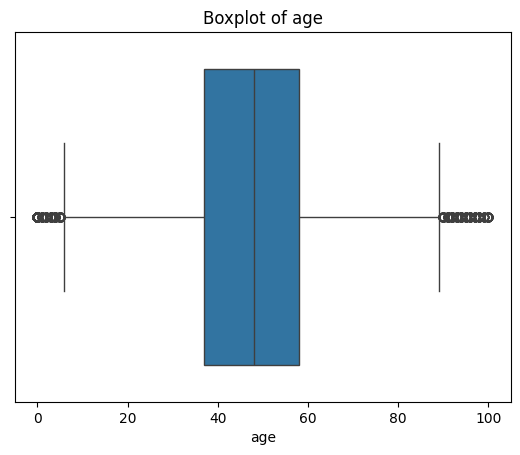

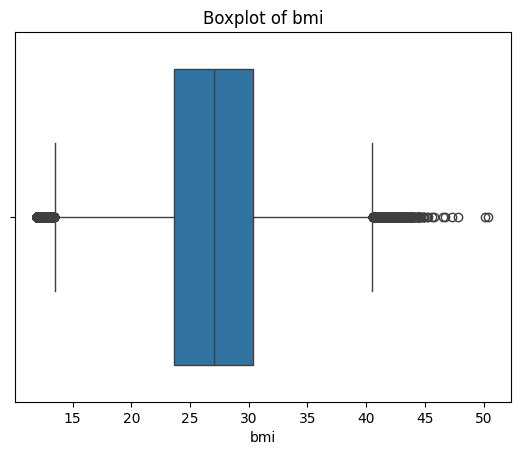

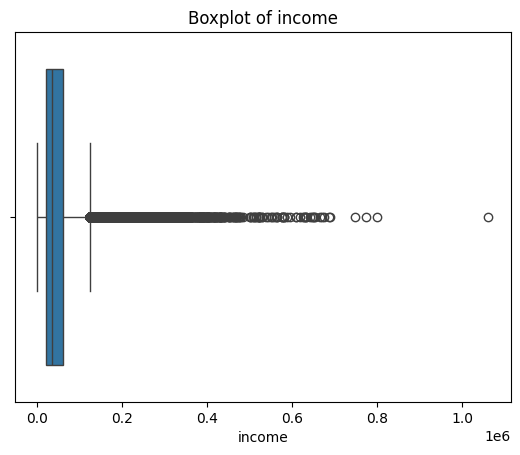

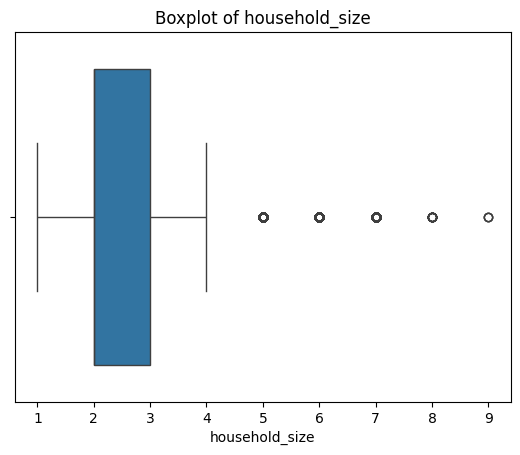

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['age', 'bmi', 'income', 'household_size']

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [22]:
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['income'] < lower) | (df['income'] > upper)]

print("outliers:", outliers.shape[0])

outliers: 6236


# Exploratory Data Analysis

### 2.1 Distribution Plots

#### Histograms of numerical features

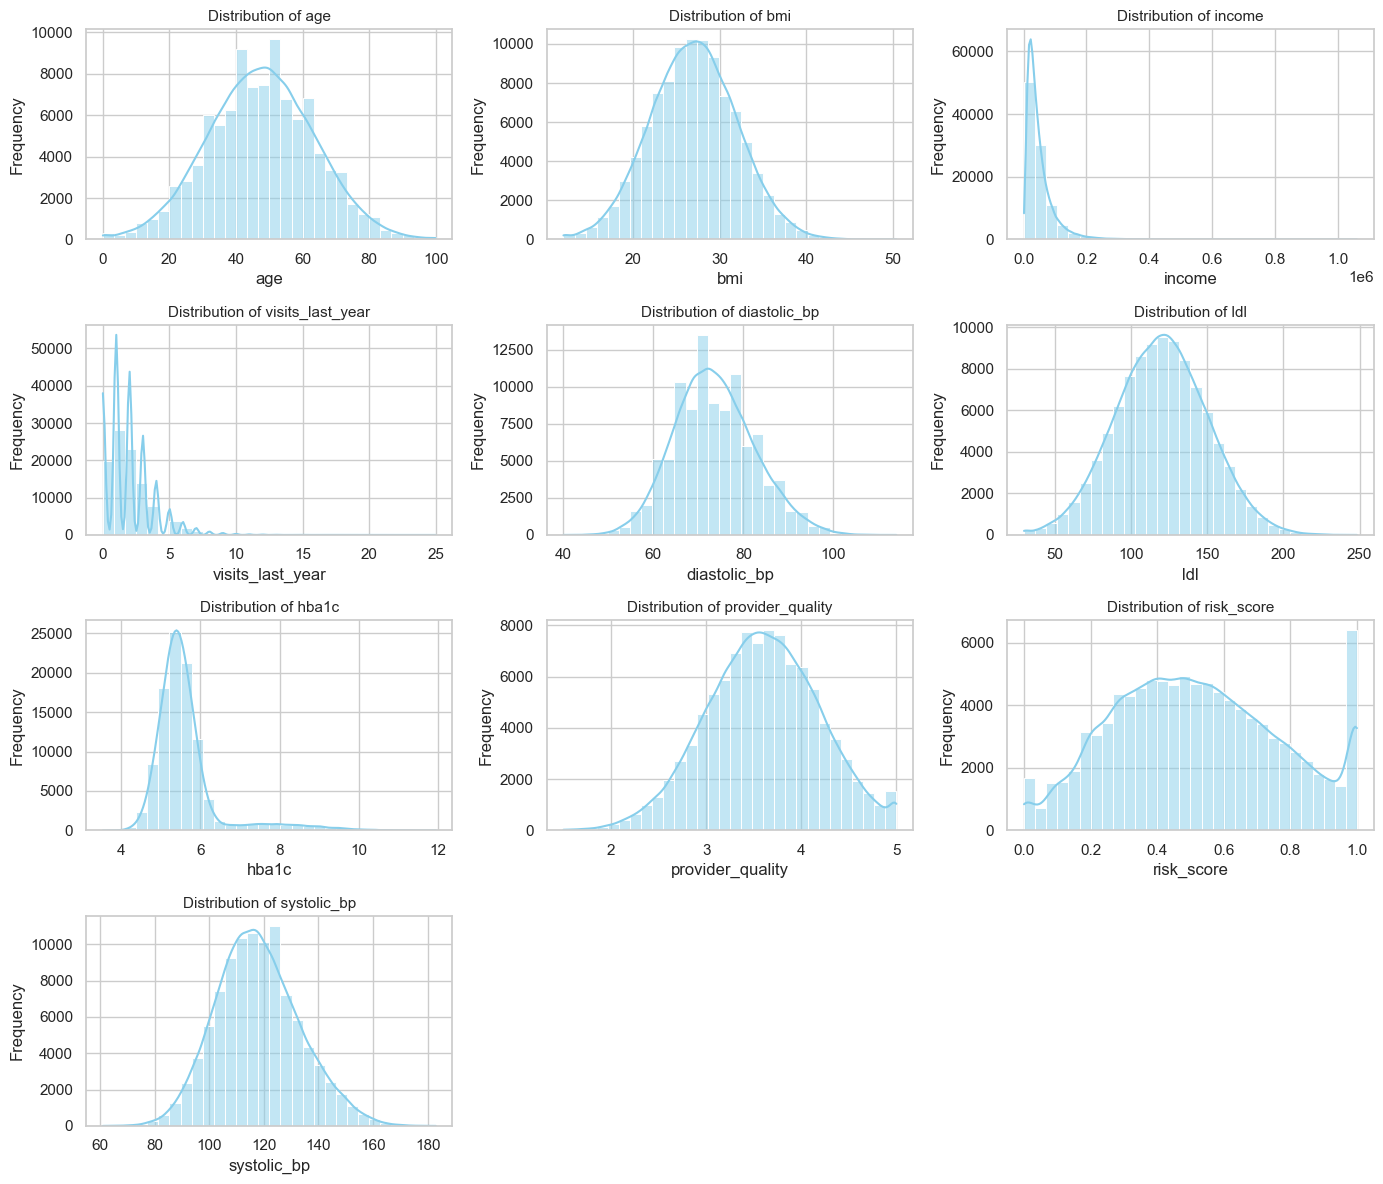

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_columns = ['age','bmi','income','visits_last_year','diastolic_bp','ldl','hba1c','provider_quality','risk_score',
                    'systolic_bp']
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()  

for i, col in enumerate(selected_columns):
    sns.histplot(df[col], kde=True, bins=30, color='skyblue', ax=axes[i])
    axes[i].set_title(f"Distribution of {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### **Distribution Analysis**

1. *Age*:
The age distribution is roughly uniform between 20–60 years, with fewer very young and very old individuals, indicating a broad adult population coverage.
2. *BMI*:
Follows a normal distribution centered around 25–30.
3. *Income*:
Highly right-skewed; most people have low to moderate income, while a few have extremely high values.
4. *Visits_last_year*:
Most individuals had 0–5 visits, showing that frequent hospital visits are relatively rare.
5. *Diastolic_BP*:
Approximately normal distribution centered at 75–85 mmHg, consistent with healthy blood pressure ranges.
6. *LDL*:
Normally distributed around 120–150, indicating typical cholesterol levels in the population.
7. *HbA1c*:
Slightly right-skewed, mostly between 4.5–6.5, meaning most individuals are within normal or prediabetic range.
8. *Provider_Quality*:
Roughly normal distribution, showing most providers have average to high-quality ratings.
9. *Risk_Score*:
Displays a bimodal or right-skewed pattern, possibly representing two groups — low-risk and high-risk patients.
10.	*Systolic_BP*:
Nearly normal distribution centered around 110 mmHg; values above 140 may indicate hypertension.

#### Plots of categorical features

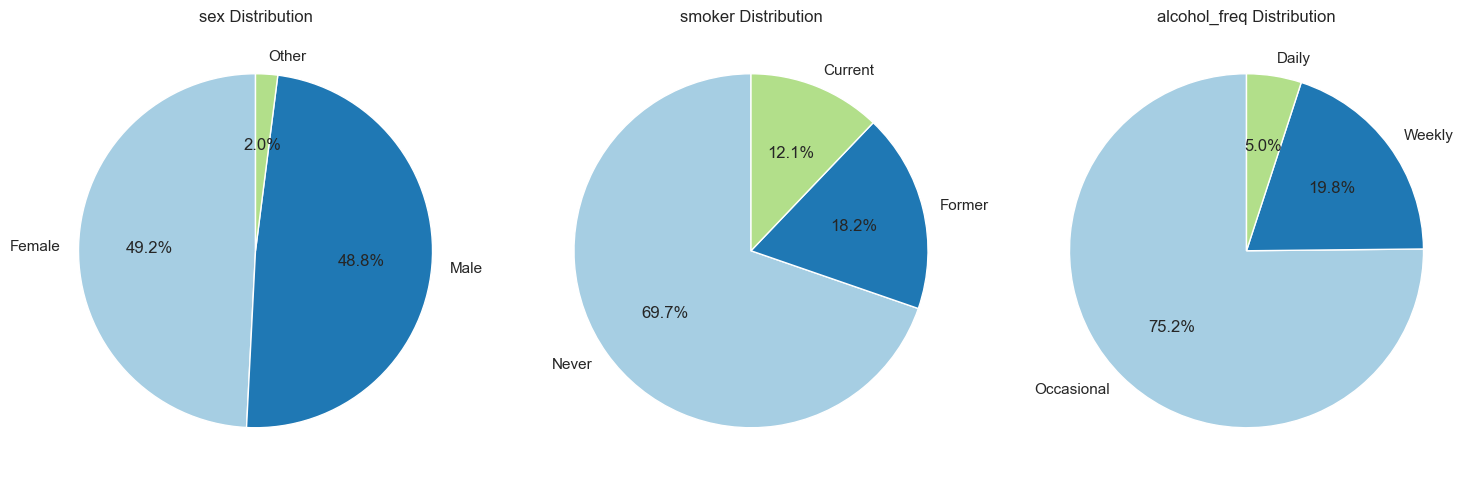

/var/folders/5y/6939r6q57sx9738c92nhs3d80000gn/T/ipykernel_21051/63788139.py:32: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.countplot(
/var/folders/5y/6939r6q57sx9738c92nhs3d80000gn/T/ipykernel_21051/63788139.py:32: UserWarning: The palette list has more values (12) than needed (6), which may not be intended.
  sns.countplot(
/var/folders/5y/6939r6q57sx9738c92nhs3d80000gn/T/ipykernel_21051/63788139.py:32: UserWarning: The palette list has more values (12) than needed (4), which may not be intended.
  sns.countplot(


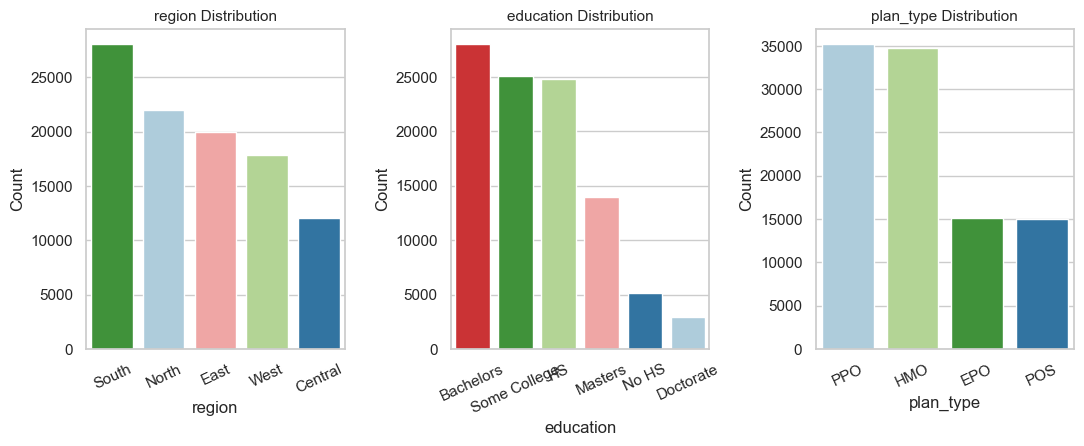

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

palette_colors = sns.color_palette("Paired")

sns.set(style="whitegrid", palette=palette_colors)

pie_columns = ['sex', 'smoker', 'alcohol_freq']
bar_columns = ['region', 'education', 'plan_type']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(pie_columns):
    counts = df[col].value_counts()
    axes[i].pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=palette_colors,
        startangle=90,
        wedgeprops={'edgecolor': 'white'}
    )
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(11, 8))
axes = axes.flatten()

for i, col in enumerate(bar_columns):
    sns.countplot(
        data=df,
        x=col,
        hue=col,  
        order=df[col].value_counts().index,
        legend=False,
        palette=palette_colors,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} Distribution', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=25)

for j in range(len(bar_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#####  **Categorical Data Analysis**
**Pie chart**
- 1.1 Sex Distribution
Balanced Sample: Near-equal gender distribution (49.2% Female, 48.8% Male)
- 1.2 Smoking Status
Majority Non-smokers: 69.7% never smoked
- 1.3 Alcohol Consumption
High Abstinence Rate: 75% occasional drink alcohol
  
**Bar chart**
- 2.1 Regional Distribution
balanced geographic coverage with the South region having the highest population representation among all areas.
- 2.2 Education Levels  
The dataset reflects diverse educational backgrounds with strong representation of college-educated individuals across all attainment levels.
- 2.3 Plan Type Preferences
PPO and HMO plans dominate the insurance market, showing clear customer preference while other plan types maintain smaller market shares.

#### Medical cost (target)

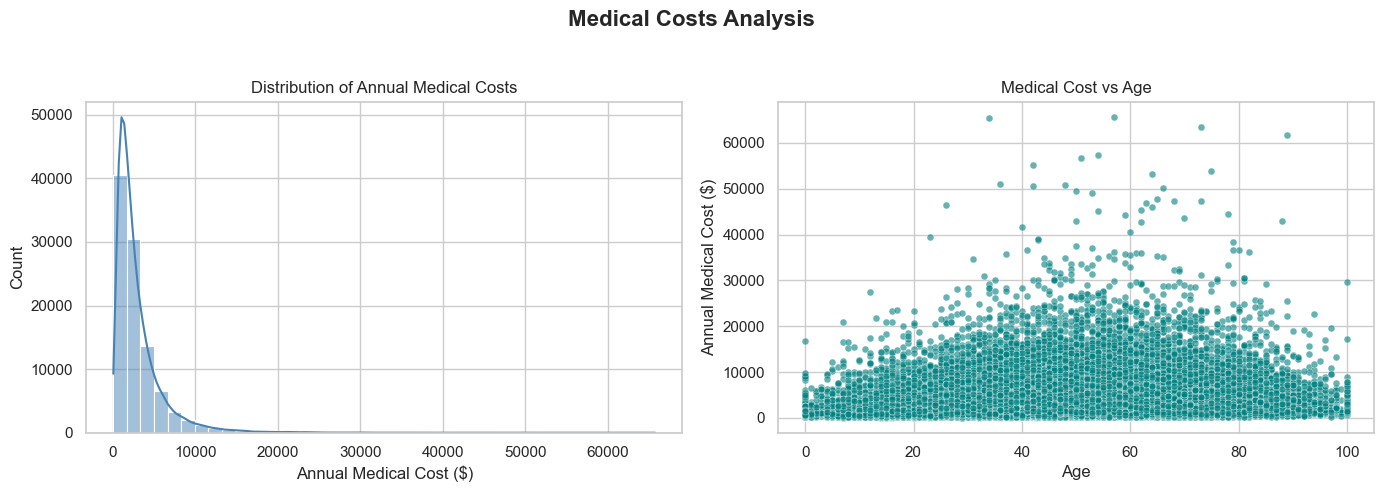

In [84]:
sns.set(style="whitegrid", palette="Paired")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Medical Costs Analysis', fontsize=16, fontweight='bold')

# 1️ Distribution of Annual Medical Costs
sns.histplot(df['annual_medical_cost'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Annual Medical Costs')
axes[0].set_xlabel('Annual Medical Cost ($)')
axes[0].set_ylabel('Count')

# 2️ Medical Cost vs Age
sns.scatterplot(data=df, x='age', y='annual_medical_cost', alpha=0.6, s=25, ax=axes[1], color='teal')
axes[1].set_title('Medical Cost vs Age')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Annual Medical Cost ($)')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

##### Medical Costs Analysis

- **Medical costs** show a right-skewed distribution, with most expenses under $20,000.
- **Age** demonstrates a positive correlation with costs, though significant variability exists across all age groups, indicating additional factors influence medical spending beyond age alone.